# **LLM Internals and RAG**

## Introduction and Overview

This notebook presents a comprehensive exploration of Large Language Models (LLMs) through two distinct methodological lenses: **Mechanistic Interpretability** and **Retrieval-Augmented Generation (RAG)**. The objective is to first understand the internal representations and information processing mechanisms of a pre-trained model, and subsequently, to enhance the factual accuracy of a generative model using external knowledge bases.

The assignment is structured into two primary sections:

### 1. Mechanistic Interpretability
The first section investigates the internal workings of **GPT-2 XL** using the `transformer_lens` library. The analysis focuses on locating and understanding knowledge representation within the model. Key procedures include:
* **Logit Lens and Activation Patching:** Analyzing hidden states to trace the flow of information and applying causal intervention techniques (patching) to identify specific layers responsible for factual recall (e.g., country-capital associations).
* **Attention Head Analysis:** Computing relation scores to evaluate how specific attention heads contribute to the model's ability to copy or relate information from the context.

### 2. Retrieval-Augmented Generation (RAG) and Evaluation
The second section establishes a complete RAG pipeline to address the hallucination limitations of static LLMs. Using **Qwen2.5-3B-Instruct** as the generator and **ChromaDB** as the vector store, the workflow includes:
* **Data Acquisition and Indexing:** Scraping and processing Wikipedia articles related to cinema (biographies and films), followed by chunking and embedding generation using `SentenceTransformer`.
* **Retrieval Pipeline:** Implementing a cosine-similarity-based retriever to fetch relevant context based on user queries.
* **Performance Analysis:** Conducting a systematic evaluation of the RAG system by varying the number of retrieved chunks ($k \in \{0, 1, 3, 5, 7\}$).
* **LLM-as-a-Judge:** Employing the LLM itself as an automated evaluator to measure accuracy against gold-standard answers, culminating in a quantitative analysis of how context window size impacts generation fidelity.

---
## Part 1: Mechanistic Interpretability
---

### **0. Setup & Imports**


In [31]:
# Installing all necessary libraries
!pip -q install -U accelerate
!pip -q install langchain-text-splitters  sentence-transformers chromadb tiktoken
!pip -q install "transformer-lens>=2.16.1" "transformers>=4.37.0" einops fancy-einsum tqdm seaborn matplotlib
print("Libraries installed successfully.")

Libraries installed successfully.


In [1]:
import random

import torch
import torch.nn.functional as F
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from transformers import AutoTokenizer, AutoModelForCausalLM
import transformer_lens


# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on device: {device}")

# Set Random Seed
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Imports ready and seed set.")

Running on device: cuda
Imports ready and seed set.


In [2]:
# Load HuggingFace Model
# Loading standard GPT2-XL
print("Loading HuggingFace gpt2-xl model...")
tokenizer = AutoTokenizer.from_pretrained("gpt2-xl")
model = AutoModelForCausalLM.from_pretrained("gpt2-xl", output_attentions=True, output_hidden_states=True)
model = model.to(device)
model.eval()
num_layers = len(model.transformer.h)
print("Model loaded successfully.")

Loading HuggingFace gpt2-xl model...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['output_attentions', 'output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded successfully.


### **1. Hooks**

Understanding how a transformer model processes information requires examining what's happening inside the model's computation. Hooks are a powerful mechanism that allow you to do exactly this. They let you "peek and play" with the intermediate computation during the forward pass, enabling inspection or even modification of data as it flows through the model.

Hooks can be attached to various components, such as:

*   Attention or MLP submodules
*   Residual streams
*   Layer weights

---

#### How Do Hooks Work?
Essentially, hooks are custom functions that you register to a specific submodule so that you can capture or alter its inputs and/or outputs at runtime.

There are two common types:
*   *Forward hooks*
*   *Forward pre-hooks*

#### PyTorch forward hook function specification
**Forward Hooks**
Run after the submodule has executed; capture or override outputs.

*Signature*

```python
def hook_fn(module, inputs, output):
```

*Specification*

| Name | Type | Description                                                                |
| -------- | ----------- | -------------------------------------------------------------------------- |
| `module` | `nn.Module` | The module the hook is registered on |
| `inputs` | `tuple`| The tuple of inputs passed into the module's `forward()` method |
| `output` | `object` | The result returned by the module — often a tensor, or a tuple of tensors |

Hooks are most commonly placed on modules like:
* `model.transformer.h[l]` — decoder module of layer `l`
* `model.transformer.h[l].attn` — Attention module of layer `l`
* `model.transformer.h[l].mlp` — MLP module of layer `l`

In transformer blocks, the `input` is usually `(hidden_states,)`, where `hidden_states` is a tensor with shape `(batch_size, sequence_length, hidden_size)`. The `output` changes depending on the module type, often for a decoder layer module it is `(hidden_states,)` or `(hidden_states, kv_cache)`. Feel free to print out each component in the hook to get a better understanding of the hook structure.

**Forward pre-hook**
Run before the submodule executes; can capture or override inputs.

*Signature*

```python
def pre_hook_fn(module, inputs):
```

*Specification*

| Name     | Type        | Description                                                                |
| -------- | ----------- | -------------------------------------------------------------------------- |
| `module` | `nn.Module` | The module that the hook is attached to |
| `inputs` | `tuple`     | The positional arguments *about to be passed* to that module's `forward()` |

*Note: There is no output argument sice this runs before the forward pass.*

`inputs` is always a tuple, even with a single tensor. Your hook can return a new tuple to modify the inputs — this is how interventions like patching are done. If your hook returns `None`, the original inputs are used unchanged.

---

#### Practicum Goal
In this practicum, we'll explore how to use hooks to access and extract activations during a model's inference pass.

---

The next step goes beyond observation: we'll write a hook to **intervene** in the inference process to influence the model's predictive behavior.

#### **Logit Lens**

The predict_next_token function implements the Logit Lens technique. It projects the hidden states of a specific layer through the model's LM Head to see what the model is predicting at that intermediate stage.

In [ ]:
def predict_next_token(hidden_states: list) -> str:
    """
    Applies the GPT-2 language modeling head to the hidden state at a given layer (i.e., logit lens),
    computes probabilities, and returns the top predicted token.
    
    """
    # Get the hidden state from the list (assuming we want the last one provided)
    # Shape: (batch_size, sequence_length, hidden_size)
    h = hidden_states[-1]

    # Select the state corresponding to the last token in the sequence
    # Shape: (batch_size, hidden_size)
    h_last = h[:, -1, :]

    # Apply the final LayerNorm (ln_f).
    # This is essential for the Logit Lens on GPT-2, as the LM head expects normalized inputs,
    # and intermediate layers have not yet passed through the final normalization.
    h_norm = model.transformer.ln_f(h_last)

    # Project through the LM Head to get logits
    # Shape: (batch_size, vocab_size)
    logits = model.lm_head(h_norm)

    # Get the token ID with the highest probability
    next_token_id = torch.argmax(logits, dim=-1)

    # Decode the token ID to a string
    next_token = tokenizer.decode(next_token_id)

    return next_token

#### **Forward Hook on an Attention Block Output**
This example demonstrates how to write a hook that captures the activations from the attention output component in layer 5. The forward hook is registered on the specific component and is triggered immediately after its computation. To prevent accumulating multiple hooks unintentionally, it is important to remove all hooks once generation is complete (unless you explicitly want them to persist).

In [4]:
# Storage dictionary to collect outputs
hook_outputs = {}

def save_attn_output_hook(module, input, output):
    component_name = "attn_output_layer5"
    hook_outputs[component_name] = output

# Register the hook on attention output in GPT-2 block 5 (index 4)
target_component = model.transformer.h[4].attn
hook_handle = target_component.register_forward_hook(save_attn_output_hook)

# Tokenize input
inputs = tokenizer("The capital of France is the city of", return_tensors="pt").to("cuda")

# Forward pass
with torch.no_grad():
    outputs = model(**inputs)

# Inspect output from the hooked layer
print(hook_outputs["attn_output_layer5"][0].shape)
# Expected: (batch_size, sequence_length, hidden_size).

# Remove hook
hook_handle.remove()

torch.Size([1, 8, 1600])


#### **Extracting the Residual Stream**
Write a forward hook that captures the **output of the residual stream** at a specific layer in GPT-2. Then, compare this output to the corresponding layer’s hidden state in `outputs.hidden_states` to confirm that your hook is capturing the same data.

In [5]:
# Storage for the residual stream output
residual_outputs = {}

def capture_residual_hook(module, inputs, output):
    """
    Captures the output of a transformer block (residual stream).
    The output of a GPT2Block is a tuple (hidden_states, ...),
    so we extract the first element.
    """
    residual_outputs["layer_4_output"] = output[0]

# Register the hook on the 5th transformer block (index 4)
layer_idx = 4
hook_handle = model.transformer.h[layer_idx].register_forward_hook(capture_residual_hook)

# Prepare input
text = "The capital of France is the city of"
inputs = tokenizer(text, return_tensors="pt").to(device)

# Run forward pass (ensure output_hidden_states=True is set in model config or call)
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

# Remove the hook to clean up
hook_handle.remove()

# Retrieve the captured tensor
hooked_tensor = residual_outputs["layer_4_output"]

# Retrieve the corresponding tensor from hidden_states
# Note: hidden_states[0] is the embedding layer output.
# hidden_states[1] is layer 0 output.
# Therefore, hidden_states[layer_idx + 1] corresponds to layer_idx output.
hf_tensor = outputs.hidden_states[layer_idx + 1]

# Verification
print(f"Hooked Tensor Shape: {hooked_tensor.shape}")
print(f"HF Hidden State Shape: {hf_tensor.shape}")

# Check for equality (using a small tolerance for floating point differences)
are_close = torch.allclose(hooked_tensor, hf_tensor, atol=1e-5)
print(f"Does the hooked residual stream match outputs.hidden_states? {are_close}")

Hooked Tensor Shape: torch.Size([1, 8, 1600])
HF Hidden State Shape: torch.Size([1, 8, 1600])
Does the hooked residual stream match outputs.hidden_states? True


#### **Intervention: Residual Stream Patching**

In this part, we'll experiment with **causal interventions** by modifying the model's residual stream. You should implement `save_hidden_states`, and then implement **both** a `patch_hook` (forward hook) **and** a `pre_patch_hook` (forward pre-hook). Although both hooks “patch” activations, they intervene at **different points** in the computation:

- A **forward pre-hook** patches the **input** to the transformer block (before the block runs).
- A **forward hook** patches the **output** of the transformer block (after the block runs).

---

1. Run inference on the `source_prompt` and extract the hidden states for `" Italy"` at `source_layer = 42`.

2. Run inference on the `target_prompt`.  
   Use the `predict_next_token` function to decode the model's answer.

3. Implement **two patching functions**:
   - `patch_hook`: a **forward hook** that patches the **block output** residual stream at a chosen layer.
   - `pre_patch_hook`: a **forward pre-hook** that patches the **block input** residual stream at a chosen layer.

4. Run inference again on the `target_prompt` **twice**:
   - Once with the **forward hook** (output patch).
   - Once with the **pre-forward hook** (input patch).  

   In both runs, patch the hidden state extracted for `" Italy"` in **Step 1** into the position of `" France"` at `target_layer = 0`.  
   Observe and compare how each patch changes the model's prediction.



##### **Caching Input Hidden States**
The `save_hidden_states` function runs a prompt through the model and extracts the hidden states associated with a specific token (provided via `substring`).

In [ ]:
def save_hidden_states(prompt: str, substring: str):

    # 1. Tokenize inputs
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"][0]

    # 2. Find the position of the substring
    # We encode the substring without special tokens to find its ID sequence
    sub_tokens = tokenizer.encode(substring, add_special_tokens=False)
    sub_len = len(sub_tokens)

    tok_pos = -1
    # Search for the substring sequence within the input_ids
    for i in range(len(input_ids) - sub_len + 1):
        if input_ids[i : i + sub_len].tolist() == sub_tokens:
            # We typically use the last token of the word/phrase as the position
            tok_pos = i + sub_len - 1
            break

    if tok_pos == -1:
        raise ValueError(f"Substring '{substring}' not found in prompt tokens.")

    # 3. Run model to get hidden states
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    # 4. Extract hidden states at the specific token position
    # outputs.hidden_states is a tuple: (embeddings, layer_0_output, layer_1_output, ...)
    tok_hidden_states = {}
    for layer_idx, layer_state in enumerate(outputs.hidden_states):
        # layer_state shape: [batch, seq_len, hidden_dim]
        # We extract the vector at the found position
        tok_hidden_states[layer_idx] = layer_state[0, tok_pos, :]

    return tok_pos, inputs, tok_hidden_states

In [7]:
source_prompt = "The capital of Italy is the city of"
italy_str = " Italy" # notice leading space
target_promp = "The capital of France is the city of"
france_str = " France"

# Layers to patch (as defined in instructions)
source_layer = 42 # Layer to extract from (Note: GPT-2 XL has 48 layers, so 42 is valid)
target_layer = 0  # Layer to patch into

# Step 1: Extract source hidden state
_, _, source_hidden_states_dict = save_hidden_states(source_prompt, italy_str)
# Get the hidden state at the specified source layer
source_hidden_state = source_hidden_states_dict[source_layer]

# Step 2: Get target info (position and inputs)
france_pos, inputs, _ = save_hidden_states(target_promp, france_str)

# Run original prediction for baseline
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)
original_prediction = predict_next_token(outputs.hidden_states)

# --- FORWARD HOOK Implementation ---

# FORWARD HOOK: Step 3
def patch_hook(module, input, output):
    # output in GPT-2 block is a tuple: (hidden_states, present, ...)
    # We need to modify the first element: hidden_states
    hidden_states = output[0]

    # We modify the tensor in-place or create a new one.
    # Important: The tensor shape is (batch, seq_len, hidden_dim).
    # We replace the vector at [0, france_pos, :] with source_hidden_state.

    # Clone to avoid in-place modification errors if needed, though usually safe here
    patched_hidden_states = hidden_states.clone()

    # Perform the patch
    patched_hidden_states[0, france_pos, :] = source_hidden_state

    # Return the modified tuple (preserving other outputs like kv-cache)
    return (patched_hidden_states,) + output[1:]

# FORWARD HOOK: Step 4
handle = model.transformer.h[target_layer].register_forward_hook(patch_hook)

with torch.no_grad():
    outputs_patched = model(**inputs, output_hidden_states=True)

handle.remove()

print(f"The original prediction:  \"{original_prediction}\"")
print(f"The forward patched prediction: \"{predict_next_token(outputs_patched.hidden_states)}\"")


# --- PRE-FORWARD HOOK Implementation ---

# PRE-FORWARD Step 3
def pre_patch_hook(module, inputs_tuple):
    # inputs_tuple to a block is usually (hidden_states, layer_past=None, ...)
    # The first element is the hidden_states tensor entering the block.
    hidden_states = inputs_tuple[0]

    # Clone to create a modified version
    patched_hidden_states = hidden_states.clone()

    # Perform the patch at the target position
    patched_hidden_states[0, france_pos, :] = source_hidden_state

    # Return the new tuple of inputs
    return (patched_hidden_states,) + inputs_tuple[1:]

# PRE-FORWARD: Step 4
handle = model.transformer.h[target_layer].register_forward_pre_hook(pre_patch_hook)

with torch.no_grad():
    outputs_pre_patched = model(**inputs, output_hidden_states=True)

handle.remove()

print(f"The pre-forward patched prediction: \"{predict_next_token(outputs_pre_patched.hidden_states)}\"")

The original prediction:  " Paris"
The forward patched prediction: " Rome"
The pre-forward patched prediction: " Rome"


In [8]:
def remove_all_handles_inplace(module):
    # forward pre/forward/backward hooks
    module._forward_hooks.clear()
    module._forward_pre_hooks.clear()
    module._backward_hooks.clear()

    # since 2.0 also:
    module._forward_hooks_with_kwargs.clear()
    module._forward_pre_hooks_with_kwargs.clear()

    for child in module.children():
        remove_all_handles_inplace(child)
remove_all_handles_inplace(model)

#### **Layer Sweep: Input vs. Output Residual Stream Patching (Rome Test)**

In the previous section, we intervened on a single manually selected layer pair. However, to fully understand where the factual knowledge (e.g., mapping "Italy" to "Rome") is located and where it is utilized, we need to perform a **comprehensive sweep** across all layers.

We will conduct this analysis in two parts to distinguish between the input and output of the transformer blocks:

1.  **Input Patching (Pre-Forward Hook):** We inject the source hidden state into the *input* of the target layer's transformer block (residual stream before the block).
2.  **Output Patching (Forward Hook):** We inject the source hidden state into the *output* of the target layer's transformer block (residual stream after the block).

Finally, we visualize both success matrices as heatmaps

In [9]:
success = np.zeros((num_layers, num_layers), dtype=bool)

# Define the target answer we are looking for
target_answer = " Rome"

print(f"Starting sweep over {num_layers} layers...")

# 1. Iterate over 'source_layer' from 0 to num_layers - 1.
for src_layer in tqdm(range(num_layers), desc="Source Layer Sweep"):
    # Retrieve the 'source_hidden_state' for the current source_layer
    # Note: We update the global variable 'source_hidden_state' because
    # the 'pre_patch_hook' defined previously likely uses it from the global scope.
    source_hidden_state = source_hidden_states_dict[src_layer]

    # 2. Iterate over 'target_layer' from 0 to num_layers - 1.
    for tgt_layer in range(num_layers):
        # Register the 'pre_patch_hook' (input patch hook) on the target layer
        # 'pre_patch_hook' is defined in the previous cell
        handle = model.transformer.h[tgt_layer].register_forward_pre_hook(pre_patch_hook)

        # Run model inference
        with torch.no_grad():
            outputs_patched = model(**inputs, output_hidden_states=True)

        # Remove the hook handle immediately
        handle.remove()

        # Predict the next token
        predicted_token = predict_next_token(outputs_patched.hidden_states)

        # Check if the patched prediction matches the target answer " Rome"
        if predicted_token == target_answer:
            success[src_layer, tgt_layer] = True

print("Sweep complete.")

Starting sweep over 48 layers...


Source Layer Sweep:   0%|          | 0/48 [00:00<?, ?it/s]

Sweep complete.


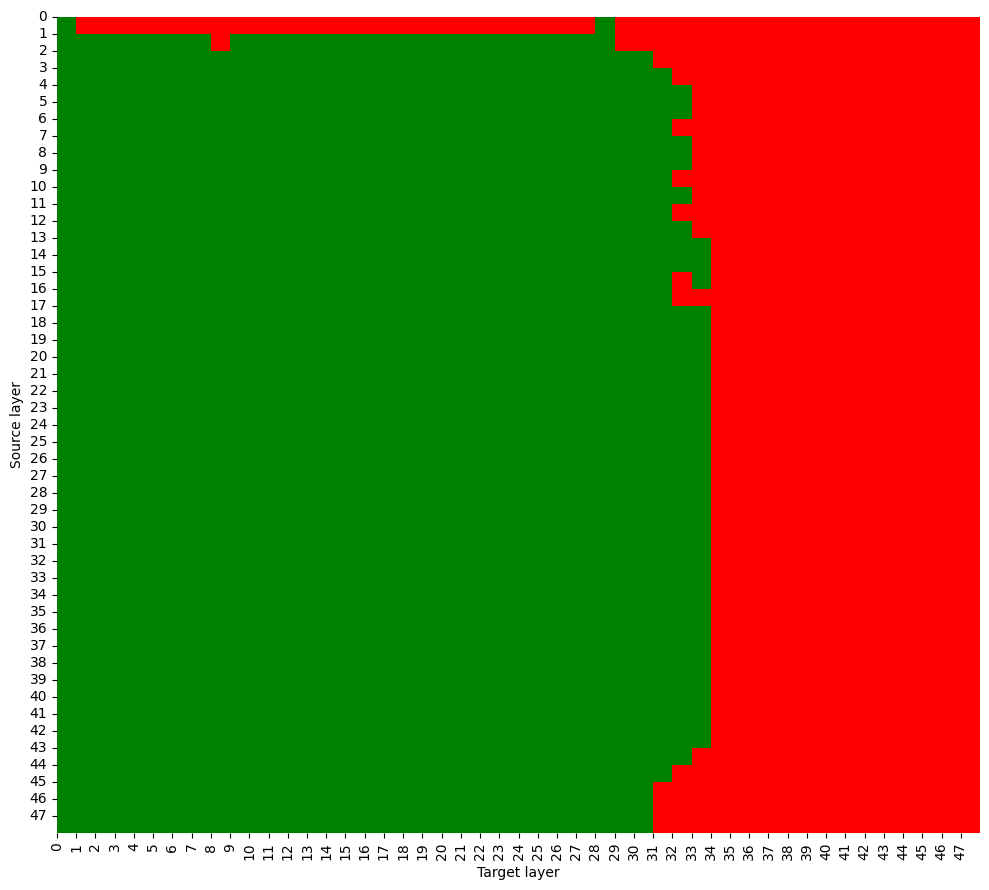

In [10]:
arr = success.astype(int)        # 1 = success, 0 = fail

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    arr,
    ax=ax,
    cmap=sns.color_palette(["red", "green"], as_cmap=True),
    cbar=False,
    square=False,
    linewidths=.0
)

ax.set_xlabel("Target layer")
ax.set_ylabel("Source layer")
ax.set_xticks(range(num_layers))
ax.set_yticks(range(num_layers))
ax.set_xticklabels(range(num_layers))
ax.set_yticklabels(range(num_layers))
plt.tight_layout()

In [11]:
success2 = np.zeros((num_layers, num_layers), dtype=bool)

# Define the target answer
target_answer = " Rome"

print(f"Starting Output Patching sweep over {num_layers} layers...")

# 1. Iterate over 'source_layer' from 0 to num_layers - 1.
for src_layer in tqdm(range(num_layers), desc="Source Layer Sweep (Output Patch)"):
    # Retrieve the 'source_hidden_state' for the current source_layer
    # Updating the global variable used by 'patch_hook'
    source_hidden_state = source_hidden_states_dict[src_layer]

    # 2. Iterate over 'target_layer' from 0 to num_layers - 1.
    for tgt_layer in range(num_layers):
        # Register the 'patch_hook' (the OUTPUT patch hook) on the transformer block
        # 'patch_hook' acts on the output of the block
        handle = model.transformer.h[tgt_layer].register_forward_hook(patch_hook)

        # Run model inference with torch.no_grad()
        with torch.no_grad():
            outputs_patched = model(**inputs, output_hidden_states=True)

        # Remove the hook handle immediately after inference
        handle.remove()

        # Predict the next token from the outputs
        predicted_token = predict_next_token(outputs_patched.hidden_states)

        # Check if the patched prediction matches the target answer
        if predicted_token == target_answer:
            success2[src_layer, tgt_layer] = True

print("Output Patching sweep complete.")

Starting Output Patching sweep over 48 layers...


Source Layer Sweep (Output Patch):   0%|          | 0/48 [00:00<?, ?it/s]

Output Patching sweep complete.


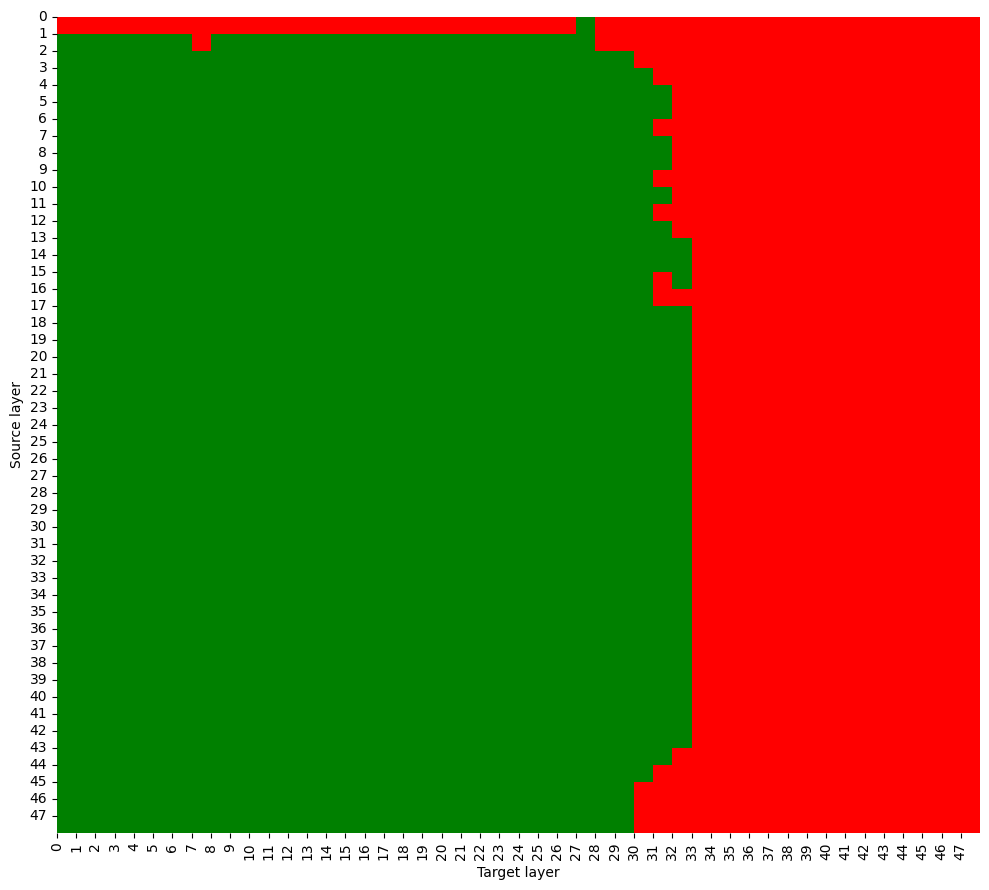

In [12]:
arr = success2.astype(int)        # 1 = success, 0 = fail

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    arr,
    ax=ax,
    cmap=sns.color_palette(["red", "green"], as_cmap=True),
    cbar=False,
    square=False,
    linewidths=.0
)

ax.set_xlabel("Target layer")
ax.set_ylabel("Source layer")
ax.set_xticks(range(num_layers))
ax.set_yticks(range(num_layers))
ax.set_xticklabels(range(num_layers))
ax.set_yticklabels(range(num_layers))
plt.tight_layout()

### **TransformerLens: Analyzing Attention Heads**
We are now transitioning to TransformerLens, a library designed to streamline mechanistic interpretability. Unlike manual PyTorch hooks, TransformerLens wraps the model to automatically capture intermediate activations into a structured ActivationCache.


In the following cells, we will use this library to perform a deeper analysis of the model's Attention Heads. Specifically, we will isolate the OV Circuit (Output-Value circuit) to determine which specific heads responsible for storing and retrieving factual associations (like "Country → Capital"). By projecting the embeddings directly through the attention heads, we can calculate "Relation Scores" to visualize which heads are acting as the model's memory.

In [13]:
import torch
import transformer_lens

if 'model' in globals():
    del model
    print("HF Model deleted.")
else:
    print("HF Model not found (already deleted or not loaded).")

torch.cuda.empty_cache()
import gc
gc.collect()
print("Memory cleared.")

print("Loading HookedTransformer gpt2-xl...")
# Loading the same model weight but wrapped in TransformerLens
model = transformer_lens.HookedTransformer.from_pretrained("gpt2-xl", device=device)
model.eval()
# Ensure tokenizer is consistent
tokenizer = model.tokenizer
cfg = model.cfg
print("HookedTransformer loaded successfully.")

HF Model deleted.
Memory cleared.
Loading HookedTransformer gpt2-xl...


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2-xl into HookedTransformer
HookedTransformer loaded successfully.


#### **Decoding of the Final Layer**


In [ ]:
# Run the model and get logits and activations
logits, activations = model.run_with_cache("The capital of France is the city of")

final_layer = model.cfg.n_layers - 1

# Note: We are taking the residual stream *before* the final block
act = activations[f"blocks.{final_layer}.hook_resid_pre"][:, -1:, :]  # shape: (1, 1, d_model)

# Apply final layer norm
# In GPT-2, the final output passes through a LayerNorm (ln_final) before the head
normalized_act = model.ln_final(act)

# Project activations to logits (Unembedding)
# model.unembed() applies the W_U matrix to project d_model -> d_vocab
manual_logits = model.unembed(normalized_act)

# Get top-k and bottom-k predictions (k=10)
k = 10
# We use torch.topk on the last dimension (vocab size)
top_vals, top_indices = torch.topk(manual_logits, k=k, dim=-1)
bottom_vals, bottom_indices = torch.topk(manual_logits, k=k, dim=-1, largest=False)

# Decode tokens to strings
# model.to_string() converts token IDs back to text
topk_tokens = model.to_string(top_indices.squeeze())
bottomk_tokens = model.to_string(bottom_indices.squeeze())

# Print top tokens
print("Top-k predictions:", topk_tokens)
print("Bottom-k predictions:", bottomk_tokens)

Top-k predictions:  Paris Lyon Marse Stras Nice Mont France Saint VersParis
Bottom-k predictions: rawdownload RandomRedditor TheNitrome�	�embedreportprint


#### **Attention Heads Analysis: The OV Circuit**

Attention heads are the core computational units in transformer models. While they are often viewed as a single mechanism, specific functionality can be better understood by decomposing a head into two independent circuits:
1.  **The QK Circuit (Query-Key):** Determines *where* to move information from (calculation of attention patterns).
2.  **The OV Circuit (Value-Output):** Determines *what* information to read and how to write it to the output.

In this practicum, we focus specifically on the **OV Circuit** to find heads that store factual mappings (e.g., "France" $\to$ "Paris").

##### Mathematical Formulation

In a standard transformer head $h$, the output contribution is calculated as:
$$
Y^{(h)} = \text{AttentionPattern} \cdot (X W_V^{(h)}) W_O^{(h)}
$$
Where $X$ is the input residual stream. We can regroup the linear transformations $W_V$ (reading values) and $W_O$ (writing to output) into a single matrix:
$$
W_{VO}^{(h)} = W_V^{(h)} W_O^{(h)} \in \mathbb{R}^{d_{model} \times d_{model}}
$$


##### Probing the Head (OV-Projection)

By ignoring the attention pattern (assuming the head attends to the source token), we can treat the head as a direct linear map. To see what a specific head "knows," we simulate its operation on a source token embedding ($E_{src}$) and project the result back into the vocabulary space using the model's unembedding matrix ($W_U$):

$$
\text{Logits} = E_{src} W_{VO}^{(h)} W_U
$$

If a head implements a "Capital City" memory, passing the embedding of "Italy" through this equation should result in high logits for the token "Rome". This is exactly what the `get_w_vo` and `ov_project` functions in the following cells will compute.

##### **Getting familiar with `state_dict`**
`state_dict` is a dictionary that holds all learnable parameters of the model, keyed by name.

```
"blocks.0.attn.W_V"     → the value projection matrix in first block
"blocks.0.attn.W_O"     → the output projection matrix in the first block
"blocks.0.mlp.W_in"     → the MLP input weights for first block
"blocks.0.ln2.w"        → the weights of the layernorm before the first MLP block
"embed.W_E"             → the input embedding matrix
"unembed.W_U"           → the output unembedding matrix
```

`state_dict["embed.W_E"][i]` represents the embedding of the token with token id `i`. For example, `state_dict["embed.W_E"][5]` is the embedding for token `5`, which corresponds to `&`.

`state_dict["embed.W_U"]`  represents the unembeddings matrix that maps hidden representations to the vocabulary space.

Each transformer block contains a multi-head self-attention module.  
For block $i$, the parameters:

- `blocks.{i}.attn.W_V` = $W_V^{(i)} \in \mathbb{R}^{d \times d_h}$
- `blocks.{i}.attn.W_O` = $W_O^{(i)} \in \mathbb{R}^{d_h \times d}$

represent the **Value projection** and **Output projection** weight matrices, respectively.

In [15]:
#  Dataset
#  The raw dataset is a list of `(country, capital)` tuples.
#  We only keep pairs where the source and target both tokenize to one token.

def preprocess_dataset(dataset):
    # Prepend space to trigger GPT-style tokenization
    dataset_ = [(" " + src, " " + dst) for src, dst in dataset]

    # Tokenize
    tokenized = [
        (tokenizer.encode(src, add_special_tokens=False),
         tokenizer.encode(dst, add_special_tokens=False))
        for src, dst in dataset_
    ]

    # Filter to one-token pairs
    filtered_pairs = [
        (orig, toks)
        for orig, toks in zip(dataset, tokenized)
        if len(toks[0]) == len(toks[1]) == 1
    ]

    filtered_dataset = [p for p, _ in filtered_pairs]
    filtered_tokenized = [t for _, t in filtered_pairs]

    src_tokens = torch.tensor([src_ids[0] for src_ids, _ in filtered_tokenized])
    dst_tokens = torch.tensor([dst_ids[0] for _, dst_ids in filtered_tokenized])

    return filtered_dataset, src_tokens, dst_tokens

In [16]:
dataset_name = "Country to capital"
dataset = [['Afghanistan', 'Kabul'], ['Albania', 'Tirana'], ['Algeria', 'Algiers'], ['Andorra', 'Andorra la Vella'], ['Angola', 'Luanda'], ['Antigua and Barbuda', "Saint John's"], ['Argentina', 'Buenos Aires'], ['Armenia', 'Yerevan'], ['Aruba', 'Oranjestad'], ['Australia', 'Canberra'], ['Austria', 'Vienna'], ['Azerbaijan', 'Baku'], ['Bahrain', 'Manama'], ['Bangladesh', 'Dhaka'], ['Belarus', 'Minsk'], ['Belgium', 'City of Brussels'], ['Benin', 'Porto-Novo'], ['Bharatpur State', 'Bharatpur'], ['Bhutan', 'Thimphu'], ['Botswana', 'Gaborone'], ['Brazil', 'Brasília'], ['Brunei', 'Bandar Seri Begawan'], ['Bulgaria', 'Sofia'], ['Burkina Faso', 'Ouagadougou'], ['Burundi', 'Gitega'], ['Cambodia', 'Phnom Penh'], ['Cameroon', 'Yaoundé'], ['Canada', 'Ottawa'], ['Cape Verde', 'Praia'], ['Catalonia', 'Barcelona'], ['Central African Republic', 'Bangui'], ['Chad', "N'Djamena"], ['Chile', 'Santiago'], ['Colombia', 'Bogotá'], ['Comoros', 'Moroni'], ['Cook Islands', 'Avarua'], ['Costa Rica', 'San José'], ['Croatia', 'Zagreb'], ['Cuba', 'Havana'], ['Cyprus', 'Nicosia'], ['Czech Republic', 'Prague'], ['Democratic Republic of the Congo', 'Kinshasa'], ['Denmark', 'Copenhagen'], ['Djibouti', 'Djibouti'], ['Dominica', 'Roseau'], ['Dominican Republic', 'Santo Domingo'], ['East Timor', 'Dili'], ['Ecuador', 'Quito'], ['Egypt', 'Cairo'], ['El Salvador', 'San Salvador'], ['England', 'London'], ['Eritrea', 'Asmara'], ['Estonia', 'Tallinn'], ['Ethiopia', 'Addis Ababa'], ['Fiji', 'Suva'], ['Finland', 'Helsinki'], ['France', 'Paris'], ['Gabon', 'Libreville'], ['Galicia', 'Santiago de Compostela'], ['Germany', 'Berlin'], ['Ghana', 'Accra'], ['Greece', 'Athens'], ['Grenada', "St. George's"], ['Guatemala', 'Guatemala City'], ['Guinea', 'Conakry'], ['Guinea-Bissau', 'Bissau'], ['Guyana', 'Georgetown'], ['Honduras', 'Tegucigalpa'], ['Hungary', 'Budapest'], ['Iceland', 'Reykjavík'], ['India', 'New Delhi'], ['Indonesia', 'Jakarta'], ['Iran', 'Tehran'], ['Iraq', 'Baghdad'], ['Ireland', 'Dublin'], ['Israel', 'Jerusalem'], ['Italy', 'Rome'], ['Ivory Coast', 'Yamoussoukro'], ['Jamaica', 'Kingston'], ['Japan', 'Tokyo'], ['Jordan', 'Amman'], ['Kazakhstan', 'Astana'], ['Kenya', 'Nairobi'], ['Kingdom of Denmark', 'Copenhagen'], ['Netherlands', 'Amsterdam'], ['Kosovo', 'Pristina'], ['Kyrgyzstan', 'Bishkek'], ['Laos', 'Vientiane'], ['Latvia', 'Riga'], ['Lebanon', 'Beirut'], ['Lesotho', 'Maseru'], ['Liberia', 'Monrovia'], ['Libya', 'Tripoli'], ['Liechtenstein', 'Vaduz'], ['Lithuania', 'Vilnius'], ['Madagascar', 'Antananarivo'], ['Malawi', 'Lilongwe'], ['Malaysia', 'Kuala Lumpur'], ['Maldives', 'Malé'], ['Mali', 'Bamako'], ['Malta', 'Valletta'], ['Mauritania', 'Nouakchott'], ['Mauritius', 'Port Louis'], ['Mexico', 'Mexico City'], ['Mongolia', 'Ulaanbaatar'], ['Montenegro', 'Podgorica'], ['Morocco', 'Rabat'], ['Mozambique', 'Maputo'], ['Myanmar', 'Naypyidaw'], ['Namibia', 'Windhoek'], ['Nauru', 'Yaren District'], ['Nepal', 'Kathmandu'], ['New Zealand', 'Wellington'], ['Nicaragua', 'Managua'], ['Niger', 'Niamey'], ['Nigeria', 'Abuja'], ['Niue', 'Alofi'], ['North Korea', 'Pyongyang'], ['North Macedonia', 'Skopje'], ['Northern Ireland', 'Belfast'], ['Northern Mariana Islands', 'Capitol Hill'], ['Norway', 'Oslo'], ['Oman', 'Muscat'], ['Pakistan', 'Islamabad'], ['Palau', 'Ngerulmud'], ['Papua New Guinea', 'Port Moresby'], ['Paraguay', 'Asunción'], ['China', 'Beijing'], ['Peru', 'Lima'], ['Philippines', 'Manila'], ['Poland', 'Warsaw'], ['Portugal', 'Lisbon'], ['Qatar', 'Doha'], ['Republic of the Congo', 'Brazzaville'], ['Romania', 'Bucharest'], ['Russia', 'Moscow'], ['Rwanda', 'Kigali'], ['Saint Kitts and Nevis', 'Basseterre'], ['Saint Lucia', 'Castries'], ['Saint Vincent and the Grenadines', 'Kingstown'], ['Samoa', 'Apia'], ['Saudi Arabia', 'Riyadh'], ['Scotland', 'Edinburgh'], ['Senegal', 'Dakar'], ['Seychelles', 'Victoria'], ['Sierra Leone', 'Freetown'], ['Sikh Confederacy', 'Amritsar'], ['Singapore', 'Singapore'], ['Sint Maarten', 'Philipsburg'], ['Slovakia', 'Bratislava'], ['Slovenia', 'Ljubljana'], ['Solomon Islands', 'Honiara'], ['Somalia', 'Mogadishu'], ['South Korea', 'Seoul'], ['South Sudan', 'Juba'], ['Spain', 'Madrid'], ['Sudan', 'Khartoum'], ['Sweden', 'Stockholm'], ['Switzerland', 'Bern'], ['Syria', 'Damascus'], ['São Tomé and Príncipe', 'São Tomé'], ['Taiwan', 'Taipei'], ['Tajikistan', 'Dushanbe'], ['Tanzania', 'Dodoma'], ['Thailand', 'Bangkok'], ['The Bahamas', 'Nassau'], ['The Gambia', 'Banjul'], ['Togo', 'Lomé'], ['Trinidad and Tobago', 'Port of Spain'], ['Tunisia', 'Tunis'], ['Turkey', 'Ankara'], ['Turkmenistan', 'Ashgabat'], ['Tuvalu', 'Funafuti'], ['Uganda', 'Kampala'], ['United Arab Emirates', 'Abu Dhabi'], ['United Kingdom', 'London'], ['United States of America', 'Washington, D.C.'], ['Uruguay', 'Montevideo'], ['Uzbekistan', 'Tashkent'], ['Vanuatu', 'Port Vila'], ['Venezuela', 'Caracas'], ['Vietnam', 'Hanoi'], ['Zambia', 'Lusaka'], ['Zimbabwe', 'Harare']]

filtered_dataset, src_tokens, dst_tokens = preprocess_dataset(dataset)

print(f"filtered_dataset[0]: {filtered_dataset[0]}")
print(f"First (src_token, dst_token): (\"{src_tokens[0]}\",\"{dst_tokens[0]}\") = (\"{tokenizer.decode(src_tokens[0])}\",\"{tokenizer.decode(dst_tokens[0])}\")")

filtered_dataset[0]: ['Afghanistan', 'Kabul']
First (src_token, dst_token): ("8037","34753") = (" Afghanistan"," Kabul")


#### **Projecting the source token embedding**
In the following exercise we will implement a couple helper functions that:

1.   For a given attention head $h$, compute the $W_{VO}^{(h)}$ matrix.
2.   Transform a set of source token embeddings $S$, by $S W_{VO}^{(h)}$.
3.   Project the transformed source token embeddings to the model's vocabulary space by computing $S W_{VO}^{(h)} U$ .

In [17]:
def get_w_vo(layer, head):
    """
    Return the composed attention projection W_VO for a given Transformer block.
    and attention head.

    Args:
        layer : int
            Zero-based index of the Transformer block to read from.
        head : int
            Zero-based index of the attention head within the block.

    Returns:
        torch.Tensor
            The composed projection matrix W_VO.
    """
    # In TransformerLens, the weights for a block are stored in:
    # model.blocks[layer].attn.W_V  -> Shape: [n_heads, d_model, d_head]
    # model.blocks[layer].attn.W_O  -> Shape: [n_heads, d_head, d_model]

    # Extract the matrices for the specific head
    W_V = model.blocks[layer].attn.W_V[head, :, :] # [d_model, d_head]
    W_O = model.blocks[layer].attn.W_O[head, :, :] # [d_head, d_model]

    # Compute the composed OV circuit: W_VO = W_V @ W_O
    # Result Shape: [d_model, d_model]
    W_VO = torch.matmul(W_V, W_O)

    return W_VO

In [ ]:
def ov_project(src_embeds, layer, head):
    """
    Given source embeddings and a particular attention head (defined by layer, head),
    embeddings are passed to get_w_vo and then projected to the vocabulary space.
    
    """
    # 1. Get the composed W_VO matrix for the specific head
    # Shape: (d_model, d_model)
    W_VO = get_w_vo(layer, head)

    # 2. Apply the OV transformation to the source embeddings
    # S @ W_VO
    # Shape: (n_srcs, d_model)
    ov_output = torch.matmul(src_embeds, W_VO)

    # 3. Project to vocabulary space using the Unembedding matrix (W_U)
    # ov_output @ W_U
    # model.W_U Shape: (d_model, d_vocab)
    # Result Shape: (n_srcs, d_vocab)
    logits = torch.matmul(ov_output, model.W_U)

    return logits

In [19]:
state_dict = model.state_dict()


# Ensure state_dict is globally available for the functions
state_dict = model.state_dict()
cfg = model.cfg

# Define is_gqa (GPT-2-xl does not use Grouped Query Attention)
is_gqa = cfg.n_key_value_heads is not None

In [20]:
# Just run this cell after implementing get_w_vo and ov_project.
state_dict = model.state_dict()


# Ensure state_dict is globally available for the functions
state_dict = model.state_dict()
cfg = model.cfg

# Define is_gqa (GPT-2-xl does not use Grouped Query Attention)
is_gqa = cfg.n_key_value_heads is not None

layer = 24
head = 4

src_embeds = state_dict["embed.W_E"][src_tokens]

# Apply the block-0 layernorm (ln2) to the source embeddings, then feed
# the normalized embeddings through the block-0 MLP.
first_mlp = lambda x: model.blocks[0].mlp.to(device)(
    model.blocks[0].ln2.to(device)(x)
)

# Applying the first mlp enriches the source embeddings and improves results in GPT-2 models.
src_embeds_ = first_mlp(src_embeds)

projected = ov_project(src_embeds_, layer, head)
print(projected.shape)

torch.Size([43, 50257])


#### **Relation Score**
To measure how strongly a head encodes a mapping from a source token to its destination, compute a **relation score**. For a given set of source tokens, the score computes the fraction of corresponding destination tokens that appear within the head's top-$k$ predictions.

In [21]:
def calc_relation_score(projected, k, dst_tokens):
    """
    Compute the proportion of destination tokens that appear in the top-k
    predictions for each sample.
    """
    # 1. Get the top-k indices for each source token
    # values, indices = torch.topk(projected, k, dim=-1)
    # indices shape: (n_srcs, k)
    _, top_indices = torch.topk(projected, k, dim=-1)

    # 2. Check if the target token is in the top-k for each sample
    # dst_tokens shape: (n_srcs,) -> unsqueeze to (n_srcs, 1) for broadcasting
    # compare (n_srcs, k) == (n_srcs, 1)
    # result is a boolean tensor of shape (n_srcs, k)
    matches = top_indices == dst_tokens.unsqueeze(1)

    # 3. Determine if *any* of the top-k matched (reduce along dim 1)
    # any_match shape: (n_srcs,)
    any_match = matches.any(dim=1)

    # 4. Calculate the mean (fraction of successes)
    # Convert boolean to float before taking the mean
    score = any_match.float().mean().item()

    return score

In [23]:
k=10
dst_tokens = dst_tokens.to(device) # Move dst_tokens to the same device as other tensors
relation_score = calc_relation_score(projected, k, dst_tokens)
print(f"The {dataset_name} relation score of head {layer}.{head} is {relation_score:.2f}")

The Country to capital relation score of head 24.4 is 0.95


#### **Putting it all together**
Now that we have a way of computing how strongly a given head implements some relation, we would like to identify all heads that do so and visualize them. Use the existing helper functions to implement a function that computes the relation scores for all heads in the model.

Follow the documentation of the `calc_relation_scores_all_heads` function, and implement it to:

1. Preprocess the dataset which is pairs of `(source token, destination token)` tuples.
2. Extract the source token embeddings.  
3. Apply the first MLP block to the source embeddings
4. For every layer and head, compute the projected transformation you implemented previously, and calculate the head's relation score.

In [ ]:
def calc_relation_scores_all_heads(dataset, k):
    """
    Compute relation scores for every (layer, head) in the model using OV-projection.

    """

    # 1. Preprocess the dataset to get single-token pairs
    # Returns: filtered_dataset (list), src_tokens (Tensor), dst_tokens (Tensor)
    _, src_tokens, dst_tokens = preprocess_dataset(dataset)

    # Ensure tensors are on the correct device
    src_tokens = src_tokens.to(device)
    dst_tokens = dst_tokens.to(device)

    # 2. Extract source token embeddings
    # model.W_E shape: [d_vocab, d_model]
    src_embeds = model.W_E[src_tokens]

    # 3. Apply the first MLP block to the source embeddings
    # As defined in the previous "Knowledge" cell, we enrich the embeddings
    # by passing them through Block 0's LayerNorm (ln2) and MLP.
    # This simulates the processing that happens before the residual stream
    # reaches the deeper attention heads.
    x_norm = model.blocks[0].ln2(src_embeds)
    src_embeds_enriched = model.blocks[0].mlp(x_norm)

    # 4. Initialize results array
    n_layers = model.cfg.n_layers
    n_heads = model.cfg.n_heads
    scores = np.zeros((n_layers, n_heads))

    print(f"Calculating scores for {n_layers} layers x {n_heads} heads...")

    # 5. Iterate over every layer and head
    for layer in tqdm(range(n_layers), desc="Layer Sweep"):
        for head in range(n_heads):
            # Project enriched embeddings through the OV circuit of this head
            logits = ov_project(src_embeds_enriched, layer, head)

            # Calculate the relation score (fraction of correct top-k predictions)
            score = calc_relation_score(logits, k, dst_tokens)

            # Store the score
            scores[layer, head] = score

    return scores

Calculating scores for 48 layers x 25 heads...


Layer Sweep:   0%|          | 0/48 [00:00<?, ?it/s]

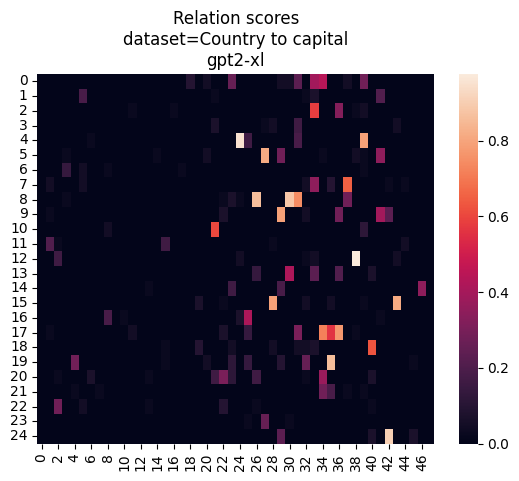

In [25]:
model_name = "gpt2-xl"

relation_scores = calc_relation_scores_all_heads(dataset, k=10)

sns.heatmap(relation_scores.T)
plt.title(f"Relation scores\ndataset={dataset_name}\n{model_name}")
plt.show()


---
## Part 2: Retrieval-Augmented Generation (RAG) and Evaluation
---

In [2]:
# Cleanup
import gc, torch

# close figures
try:
    import matplotlib.pyplot as plt
    plt.close("all")
except Exception:
    pass

# delete big objects
for name in ["model", "tokenizer", "cfg", "state_dict", "act_generator", "nmf",
             "activations", "cache", "hook_outputs", "outputs", "outputs_patched",
             "relation_scores", "success", "success2"]:
    if name in globals():
        del globals()[name]

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

### **0. Setup & Imports**

In [3]:
# Import all necessary library for RAG
import os
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path
import time
import random
import requests
from urllib.parse import quote
from langchain_core.documents import Document
import re
from typing import List, Dict, Any, Optional
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb
import hashlib
import json
import torch
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt

### **1. Data Acquisition and Verification**

This section implements the data retrieval pipeline by defining a function to fetch specific biography and film articles via the MediaWiki API. After downloading the content to construct our raw knowledge base, we inspect a snippet of the first document to verify the data integrity.

In [4]:
# Set a custom User-Agent for API requests
USER_AGENT = "HW5_GM/1.0 (educational use; contact: sut-cs-gm.github.io)"

# Reuse one HTTP session for efficiency
session = requests.Session()
session.headers.update({
    "User-Agent": USER_AGENT,
    "Api-User-Agent": USER_AGENT,
    "Accept": "application/json",
})

# Page titles: biographies
biography_titles = [
    "Steven Spielberg", "Quentin Tarantino", "James Cameron", "Stanley Kubrick", "Ridley Scott",
    "David Fincher", "Denis Villeneuve", "Hayao Miyazaki", "Bong Joon-ho", "Wong Kar-wai",
    "Pedro Almodóvar", "Federico Fellini", "Ingmar Bergman", "Satyajit Ray", "Spike Lee",
    "Greta Gerwig", "Sofia Coppola", "Kathryn Bigelow", "Guillermo del Toro", "Alfonso Cuarón",
    "Ang Lee", "Wes Anderson", "Tim Burton", "Charlie Chaplin", "Audrey Hepburn",
]

# Page titles: films
film_titles = [
    "The Godfather", "The Godfather Part II", "Pulp Fiction", "Taxi Driver", "Raging Bull",
    "Casablanca", "Vertigo (film)", "Psycho (1960 film)", "2001: A Space Odyssey", "Schindler's List",
    "Jurassic Park (film)", "The Matrix", "Fight Club", "Blade Runner", "Spirited Away",
    "Parasite (film)", "Goodfellas", "Apocalypse Now", "The Silence of the Lambs (film)",
    "The Lord of the Rings: The Fellowship of the Ring", "The Lord of the Rings: The Return of the King",
    "Star Wars (film)", "The Empire Strikes Back", "Pan's Labyrinth", "Roma (2018 film)",
]

# HTTP GET with retries (rate limits / server errors)
def _request_with_retry(url, params, max_retries=6, timeout=30):
    for attempt in range(max_retries):
        resp = session.get(url, params=params, timeout=timeout)

        if resp.status_code == 200:
            return resp

        if resp.status_code in (429, 500, 502, 503, 504):
            sleep_s = (2 ** attempt) + random.uniform(0.2, 0.8)
            print(f"Retryable HTTP {resp.status_code}. Sleeping {sleep_s:.1f}s ...")
            time.sleep(sleep_s)
            continue


        detail = (resp.text or "")[:300]
        raise requests.HTTPError(
            f"HTTP {resp.status_code} for {resp.url}\n"
            f"Response (first 300 chars): {detail}",
            response=resp
        )

    raise requests.HTTPError(f"Failed after {max_retries} retries. Last URL: {resp.url}", response=resp)

def fetch_wikipedia_documents(titles, category, lang="en", exintro=False, sleep_range=(0.2, 0.6)):
    api_url = f"https://{lang}.wikipedia.org/w/api.php"
    docs = []

    print(f"Fetching {len(titles)} Wikipedia pages for category='{category}' ...")

    for i, title in enumerate(titles, start=1):
        params = {
            "action": "query",
            "format": "json",
            "formatversion": 2,
            "prop": "extracts",
            "explaintext": 1,            # plain text (no HTML/<a>)
            "exsectionformat": "plain",
            "redirects": 1,
            "titles": title,
            "maxlag": 5,
        }
        if exintro:
            params["exintro"] = 1

        r = _request_with_retry(api_url, params=params)
        data = r.json()

        pages = (data.get("query", {}) or {}).get("pages", []) or []
        if not pages:
            print(f"Skipped (no pages): {title}")
            continue

        p = pages[0]
        page_title = p.get("title", title)
        extract = (p.get("extract", "") or "").strip()

        if p.get("missing") is True or extract == "":
            print(f"Skipped (missing/empty extract): {page_title}")
            continue

        pageid = p.get("pageid", None)
        safe_title = quote(page_title.replace(" ", "_"), safe="()'_-")
        page_url = f"https://{lang}.wikipedia.org/wiki/{safe_title}"

        docs.append(
            Document(
                page_content=extract,
                metadata={
                    "source_file": page_title,
                    "file_type": "wikipedia",
                    "source": "wikipedia",
                    "language": lang,
                    "category": category,
                    "page_title": page_title,
                    "pageid": pageid,
                    "source_url": page_url,
                },
            )
        )


        time.sleep(random.uniform(*sleep_range))

        if i % 10 == 0:
            print(f"Progress: {i}/{len(titles)}")

    print(f"Loaded {len(docs)} Wikipedia Documents successfully (category='{category}').")
    return docs

# Load both categories
bio_docs = fetch_wikipedia_documents(biography_titles, category="biography", lang="en")
film_docs = fetch_wikipedia_documents(film_titles, category="film", lang="en")

# Merge all docs
all_wiki_docs = bio_docs + film_docs
print(f"\nTotal documents loaded: {len(all_wiki_docs)}")

Fetching 25 Wikipedia pages for category='biography' ...
Progress: 10/25
Progress: 20/25
Loaded 25 Wikipedia Documents successfully (category='biography').
Fetching 25 Wikipedia pages for category='film' ...
Progress: 10/25
Progress: 20/25
Loaded 25 Wikipedia Documents successfully (category='film').

Total documents loaded: 50


In [5]:
# Show the first loaded document

doc = all_wiki_docs[0]
print(f"Content snippet:\n{doc.page_content[:250]}...")

Content snippet:
Steven Allan Spielberg (; born December 18, 1946) is an American filmmaker. A major figure of the New Hollywood era and pioneer of the modern blockbuster, Spielberg is widely regarded as one of the greatest and most influential filmmakers in the hist...


### **Chunking and Inspecting Wikipedia Documents**

In this section, we prepare the raw Wikipedia pages for Retrieval-Augmented Generation (RAG) by converting each article into smaller, searchable chunks. We first clean and split the documents with a controlled chunk size and overlap, then we quickly inspect a few sample chunks and their metadata to verify the chunking quality before moving to embedding and indexing.


In [6]:
import re

# Chunk Wikipedia documents for RAG

def preprocess_wikipedia_text(text: str) -> str:
    """
    Cleaning for Wikipedia plain-text extracts.
    - Remove very common low-signal tail sections
    - Normalize whitespace
    """
    if not text:
        return ""

    # Cut off common tail sections that usually add noise for retrieval
    cut_patterns = [
        r"\n\nSee also\n",
        r"\n\nReferences\n",
        r"\n\nSources\n",
        r"\n\nFurther reading\n",
        r"\n\nExternal links\n",
        r"\n\nBibliography\n",
        r"\n\nNotes\n",
    ]
    for pat in cut_patterns:
        m = re.search(pat, text, flags=re.IGNORECASE)
        if m:
            text = text[:m.start()].strip()
            break

    # Normalize whitespace (keep paragraph structure)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

def split_text_manually(text, chunk_size, chunk_overlap):
    """
    A simple sliding window splitter to replace LangChain if missing.
    """
    chunks = []
    start = 0
    text_len = len(text)

    if text_len == 0:
        return []

    # If text is shorter than chunk size, return it as one chunk
    if text_len <= chunk_size:
        return [text]

    while start < text_len:
        end = min(start + chunk_size, text_len)
        chunk = text[start:end]
        chunks.append(chunk)

        # Stop if we have reached the end
        if end == text_len:
            break

        # Move forward by step size (chunk_size - overlap)
        step = chunk_size - chunk_overlap
        start += step

    return chunks

def split_wikipedia_documents(
    documents,
    chunk_size_tokens=350,
    chunk_overlap_tokens=60,
    chunk_size_chars=1200,
    chunk_overlap_chars=200
):
    """
    Turns raw documents into clean, indexed chunks using a manual splitter
    to avoid dependency errors.
    """

    # 1. Filter documents: Keep only Wikipedia pages
    filtered_docs = [doc for doc in documents if doc.metadata.get("file_type") == "wikipedia"]
    print(f"Filtered to {len(filtered_docs)} valid Wikipedia documents.")

    # 2. Clean the text
    cleaned_docs = []
    for doc in filtered_docs:
        cleaned_content = preprocess_wikipedia_text(doc.page_content)
        if cleaned_content:
            # We create a shallow copy to keep original safe if needed
            # (Here we just modify the object for the pipeline)
            doc.page_content = cleaned_content
            cleaned_docs.append(doc)

    # 3. Split and 4. Attach Metadata
    final_chunks = []

    print(f"Using Manual Character-based splitter (size={chunk_size_chars}, overlap={chunk_overlap_chars})")

    for doc in cleaned_docs:
        # Split using the manual helper function
        raw_chunks = split_text_manually(
            doc.page_content,
            chunk_size=chunk_size_chars,
            chunk_overlap=chunk_overlap_chars
        )

        base_metadata = doc.metadata.copy()

        for i, chunk_text in enumerate(raw_chunks):
            # Create metadata for this specific chunk
            chunk_metadata = base_metadata.copy()
            chunk_metadata["chunk_id"] = f"{base_metadata.get('pageid', 'unknown')}_{i}"
            chunk_metadata["chunk_index"] = i

            # Create the Document object (assuming Document class exists from previous cells)
            # If Document is from langchain and missing, we use a simple dict or class
            try:
                new_doc = Document(page_content=chunk_text, metadata=chunk_metadata)
            except NameError:
                # Fallback class if Document is not defined
                class SimpleDoc:
                    def __init__(self, page_content, metadata):
                        self.page_content = page_content
                        self.metadata = metadata
                new_doc = SimpleDoc(page_content=chunk_text, metadata=chunk_metadata)

            final_chunks.append(new_doc)

    # 5. Sanity check (preview)
    if final_chunks:
        print(f"\nTotal chunks generated: {len(final_chunks)}")
        print("--- Sample Chunk 0 ---")
        print(f"ID: {final_chunks[0].metadata['chunk_id']}")
        print(f"Content Preview: {final_chunks[0].page_content[:150]}...")
    else:
        print("Warning: No chunks were generated.")

    return final_chunks

# Create chunks from loaded Wikipedia docs
wiki_chunks = split_wikipedia_documents(all_wiki_docs)

Filtered to 50 valid Wikipedia documents.
Using Manual Character-based splitter (size=1200, overlap=200)

Total chunks generated: 2149
--- Sample Chunk 0 ---
ID: 26940_0
Content Preview: Steven Allan Spielberg (; born December 18, 1946) is an American filmmaker. A major figure of the New Hollywood era and pioneer of the modern blockbus...


In [7]:
# Display the first 3 chunks (content preview + metadata)

for i, ch in enumerate(wiki_chunks[:3]):
    print("=" * 60)
    print(f"CHUNK #{i} | source_file: {ch.metadata.get('source_file')} | category: {ch.metadata.get('category')} | chunk_id: {ch.metadata.get('chunk_id')}")
    print("-" * 60)
    print(ch.page_content[:100])  # show first 100 chars from each chunk
    print("\nMetadata:", ch.metadata)

CHUNK #0 | source_file: Steven Spielberg | category: biography | chunk_id: 26940_0
------------------------------------------------------------
Steven Allan Spielberg (; born December 18, 1946) is an American filmmaker. A major figure of the Ne

Metadata: {'source_file': 'Steven Spielberg', 'file_type': 'wikipedia', 'source': 'wikipedia', 'language': 'en', 'category': 'biography', 'page_title': 'Steven Spielberg', 'pageid': 26940, 'source_url': 'https://en.wikipedia.org/wiki/Steven_Spielberg', 'chunk_id': '26940_0', 'chunk_index': 0}
CHUNK #1 | source_file: Steven Spielberg | category: biography | chunk_id: 26940_1
------------------------------------------------------------
Night Gallery and Columbo, he directed the television film Duel (1971), which was approved by Barry 

Metadata: {'source_file': 'Steven Spielberg', 'file_type': 'wikipedia', 'source': 'wikipedia', 'language': 'en', 'category': 'biography', 'page_title': 'Steven Spielberg', 'pageid': 26940, 'source_url': 'https://en

### **Embedding Generation**
In this step, we initialize the embedding model using the SentenceTransformer library to convert text chunks into dense vector representations. The embeddings are normalized to ensure accurate cosine similarity calculations during the retrieval process.

In [8]:
# Embedding helper class

class EmbeddingData:
    """A wrapper around SentenceTransformer for generating normalized embeddings."""

    def __init__(self, model_name: str = "all-MiniLM-L6-v2", device: Optional[str] = None):
        """
        Args:
            model_name: Sentence-Transformers model name
            device: "cuda" or "cpu". If None, SentenceTransformer auto-selects.
        """
        self.model_name = model_name
        self.device = device
        self.model = None
        self._load_model()

    def _load_model(self):
        """Load the embedding model once."""
        print(f"Loading embedding model: {self.model_name}")
        if self.device:
            self.model = SentenceTransformer(self.model_name, device=self.device)
        else:
            self.model = SentenceTransformer(self.model_name)
        print(f"Model loaded. Embedding dim: {self.model.get_sentence_embedding_dimension()}")

    def generate_embeddings(
        self,
        texts: List[str],
        batch_size: int = 64,
        show_progress_bar: bool = True,
        normalize: bool = True,
    ) -> np.ndarray:
        """
        Generate embeddings for a list of texts.

        Note:
            - normalize=True makes cosine similarity search more stable/effective.
        """
        if not texts:
            dim = self.model.get_sentence_embedding_dimension()
            return np.empty((0, dim), dtype=np.float32)

        embeddings = self.model.encode(
            texts,
            batch_size=batch_size,
            show_progress_bar=show_progress_bar,
            convert_to_numpy=True,
            normalize_embeddings=normalize,
        )
        return embeddings.astype(np.float32)


# Auto-pick device
try:
    import torch
    device = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    device = None

embedding_data = EmbeddingData(device=device)

Loading embedding model: all-MiniLM-L6-v2
Model loaded. Embedding dim: 384


### **Building the Vector Database**
In this section, we define the VectorStore class to manage the persistent ChromaDB interface and enforce cosine similarity. We then execute the indexing pipeline by generating normalized embeddings for all chunks and upserting them into the database to enable semantic retrieval.

In [9]:
import hashlib
import os
import chromadb
from typing import Dict, Any, List

# Build a ChromaDB vector store for Wikipedia chunks
class VectorStore:
    """Stores chunks + embeddings in a ChromaDB collection (persistent)."""

    def __init__(
        self,
        collection_name: str = "wiki_cinema_chunks",
        persist_dir: str = "wiki_vector_store",
        space: str = "cosine",
    ):
        self.collection_name = collection_name
        self.persist_dir = persist_dir
        self.space = space

        self.client = None
        self.collection = None
        self._init_vector_store()

    def _init_vector_store(self):
        # Ensure persistence directory exists (for on-disk storage)
        os.makedirs(self.persist_dir, exist_ok=True)

        # Create / reuse a persistent Chroma client
        self.client = chromadb.PersistentClient(path=self.persist_dir)

        # Create (or load) a collection and configure ANN index distance metric (HNSW space)
        try:
            self.collection = self.client.get_or_create_collection(
                name=self.collection_name,
                embedding_function=None,
                configuration={"hnsw": {"space": self.space}},
                metadata={"description": "Wikipedia cinema corpus (chunks) for RAG"},
            )
        except TypeError:
            # Backward-compatible fallback for older Chroma versions
            self.collection = self.client.get_or_create_collection(
                name=self.collection_name,
                metadata={
                    "hnsw:space": self.space,
                    "description": "Wikipedia cinema corpus (chunks) for RAG",
                },
            )

        # Try to read the effective (actual) space from the collection configuration (if available)
        actual_space = None
        cfg = getattr(self.collection, "configuration", None)
        if isinstance(cfg, dict):
            actual_space = (cfg.get("hnsw") or {}).get("space")

        print(f"Vector store ready: {self.collection_name}")
        print(f"Requested space = {self.space} | Actual space = {actual_space or 'unknown'}")
        print(f"Existing chunks in collection: {self.collection.count()}")

        # Fail if the collection uses a different distance metric than expected
        if actual_space is not None and actual_space != self.space:
            raise ValueError(
                f"Collection '{self.collection_name}' space is '{actual_space}', but you expect '{self.space}'. "
                f"This will break your cosine-sim logic."
            )

    @staticmethod
    def _sanitize_metadata(md: Dict[str, Any]) -> Dict[str, Any]:
        """
        ChromaDB metadata must be JSON-serializable. Here we keep only primitive types
        and convert anything else to string.
        """
        if md is None:
            return {}

        clean_md = {}
        for key, value in md.items():
            # Drop None values
            if value is None:
                continue

            # Keep primitives, stringify others
            if isinstance(value, (str, int, float, bool)):
                clean_md[key] = value
            else:
                clean_md[key] = str(value)

        return clean_md

    @staticmethod
    def _stable_chunk_id(chunk) -> str:
        """
        Create a stable ID for each chunk to prevent duplicates on re-runs.
        """
        # 1. Pick a stable source key
        md = chunk.metadata
        # Prefer pageid, then URL, then filename, default to 'unknown'
        source_key = str(md.get("pageid") or md.get("source_url") or md.get("source_file") or "unknown")

        # 2. Combine source key + chunk text
        # Using the actual content ensures that if chunking changes, ID changes
        combined_str = f"{source_key}_{chunk.page_content}"

        # 3. Hash the combined string (SHA1) and take short prefix
        hash_digest = hashlib.sha1(combined_str.encode("utf-8")).hexdigest()[:16]

        # 4. Return ID
        return f"wiki_{hash_digest}"

    def add_chunks(self, chunks: List[Any], embeddings):
        """
        Upsert chunks + embeddings into ChromaDB
        """
        # 1. Validate inputs
        if len(chunks) != len(embeddings):
            raise ValueError(f"Mismatch: {len(chunks)} chunks vs {len(embeddings)} embeddings")

        ids = []
        documents = []
        metadatas = []
        embeddings_list = []

        seen_ids = set()

        # 2. Process each chunk
        for chunk, emb in zip(chunks, embeddings):
            chunk_id = self._stable_chunk_id(chunk)

            # 3. Ensure IDs are unique inside the batch
            if chunk_id in seen_ids:
                continue
            seen_ids.add(chunk_id)

            ids.append(chunk_id)
            documents.append(chunk.page_content)
            metadatas.append(self._sanitize_metadata(chunk.metadata))

            # Convert numpy array to list for Chroma
            if hasattr(emb, "tolist"):
                embeddings_list.append(emb.tolist())
            else:
                embeddings_list.append(emb)

        if not ids:
            print("No new unique chunks to add.")
            return

        # 4. Upsert into collection
        self.collection.upsert(
            ids=ids,
            embeddings=embeddings_list,
            documents=documents,
            metadatas=metadatas
        )

        # 5. Print status
        print(f"Upserted {len(ids)} chunks. Total collection count: {self.collection.count()}")

# Initialize the vector store
vectorstore = VectorStore(
    collection_name="wiki_cinema_chunks",
    persist_dir="wiki_vector_store",
    space="cosine",
)

Vector store ready: wiki_cinema_chunks
Requested space = cosine | Actual space = cosine
Existing chunks in collection: 2149


In [10]:
# Convert chunks -> embeddings -> store in vector DB

# 1) Extract chunk texts
chunk_texts = [ch.page_content for ch in wiki_chunks]
print(f"Total chunks to embed: {len(chunk_texts)}")

# 2) Generate embeddings (normalized for cosine)
chunk_embeddings = embedding_data.generate_embeddings(
    chunk_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize=True,
)
print(f"Embeddings shape: {chunk_embeddings.shape}")

# 3) Store into ChromaDB
vectorstore.add_chunks(wiki_chunks, chunk_embeddings)

Total chunks to embed: 2149


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

Embeddings shape: (2149, 384)
Upserted 2149 chunks. Total collection count: 2149


### **Retrieval Pipeline and Testing**
In this section, we implement the RetrieverRAG class to orchestrate semantic search by converting user queries into embeddings and ranking results based on cosine similarity. This class also handles the construction of the final context string that will be fed into the LLM. Finally, we validate the system's accuracy by running a sanity check with a sample query to visually inspect the relevance of the retrieved chunks.


In [11]:
# Query Retrieval Pipeline (Cosine similarity)

class RetrieverRAG:
    """Query-time retrieval from a Chroma vector store using cosine similarity."""

    def __init__(self, vector_store: VectorStore, embedding_data: EmbeddingData):
        self.vector_store = vector_store
        self.embedding_data = embedding_data

        # Enforce cosine usage
        if getattr(self.vector_store, "space", None) != "cosine":
            raise ValueError("This RetrieverRAG is designed ONLY for cosine space. Please set VectorStore(space='cosine').")

    @staticmethod
    def _cosine_similarity_from_distance(distance: float) -> float:
        """cosine_similarity = 1 - cosine_distance"""
        sim = 1.0 - float(distance)
        if sim > 1.0:
            sim = 1.0
        if sim < -1.0:
            sim = -1.0
        return sim

    def retrieve(self, query: str, top_k: int = 5, min_similarity: float = 0.0) -> List[Dict[str, Any]]:
        """
        Retrieves top-k relevant chunks for a query using semantic search.
        """
        # 1) Clean/validate query
        query = query.strip()
        if not query:
            return []

        # 2) Embed the query
        # We wrap query in a list as generate_embeddings expects a list of strings
        query_emb = self.embedding_data.generate_embeddings([query], normalize=True)[0].tolist()

        # 3) Query ChromaDB
        results = self.vector_store.collection.query(
            query_embeddings=[query_emb],
            n_results=top_k,
            include=["documents", "metadatas", "distances"]
        )

        # Chroma returns lists of lists; extract the first (and only) query result
        ids = results.get("ids", [[]])[0]
        texts = results.get("documents", [[]])[0]
        metadatas = results.get("metadatas", [[]])[0]
        distances = results.get("distances", [[]])[0]

        output = []
        # 4) Convert distance -> similarity and 5) Filter
        for i in range(len(ids)):
            sim = self._cosine_similarity_from_distance(distances[i])

            if sim >= min_similarity:
                # 6) Build output format
                output.append({
                    "id": ids[i],
                    "chunk_text": texts[i],
                    "similarity": sim,
                    "metadata": metadatas[i]
                })

        # 7) Sort and rank
        output.sort(key=lambda x: x["similarity"], reverse=True)
        for rank, item in enumerate(output, 1):
            item["rank"] = rank

        return output

    def build_context(self, retrieved: List[Dict[str, Any]], max_chars_per_chunk: Optional[int] = None) -> str:
        """
        Formats retrieved results into a readable context block for the LLM.
        """
        if not retrieved:
            return ""

        context_blocks = []
        # 1) Iterate through items
        for item in retrieved:
            md = item["metadata"]
            source = md.get("page_title") or md.get("source_file") or "Unknown"
            cid = md.get("chunk_id") or item["id"]
            sim = item["similarity"]

            # 2) Optionally truncate text
            text = item["chunk_text"]
            if max_chars_per_chunk and len(text) > max_chars_per_chunk:
                text = text[:max_chars_per_chunk] + "..."

            # 3) Create header and 4) Concatenate blocks
            header = f"[Source: {source} | Chunk: {cid} | Similarity: {sim:.4f}]"
            block = f"{header}\n{text}"
            context_blocks.append(block)

        # 5) Join blocks with separator
        return "\n\n---\n\n".join(context_blocks).strip()

    def retrieve_context(self, query: str, top_k: int, min_similarity: float = 0.0, max_chars_per_chunk: Optional[int] = None) -> str:
        """
        Convenience wrapper for retrieval + formatting.
        """
        # 1) Retrieve
        retrieved_items = self.retrieve(query, top_k=top_k, min_similarity=min_similarity)

        # 2) Build context
        formatted_context = self.build_context(retrieved_items, max_chars_per_chunk=max_chars_per_chunk)

        # 3) Return
        return formatted_context

# Initialize the RAG retriever
retriever_rag = RetrieverRAG(vectorstore, embedding_data)

In [12]:
# Test retrieval using the first loaded Wikipedia document as a query seed

first_doc = all_wiki_docs[0]
doc_title = first_doc.metadata.get("page_title", first_doc.metadata.get("source_file", "Unknown Title"))

# Take a short snippet from the beginning of the document as query context
snippet = first_doc.page_content.strip().split("\n")[0][:220]

test_query = f"{doc_title}. {snippet}"
print("Test query:")
print(test_query)

top_results = retriever_rag.retrieve(test_query, top_k=5, min_similarity=0.0)

# Display retrieved Top-5 chunks (preview) so we can judge relevance
for item in top_results:
    print("=" * 60)
    print(f"RANK #{item['rank']} | similarity: {item['similarity']:.4f} | id: {item['id']}")
    md = item["metadata"] or {}
    print(f"source_file: {md.get('source_file')} | category: {md.get('category')} | chunk_id: {md.get('chunk_id')}")
    print("-" * 60)
    print(item["chunk_text"][:900])

Test query:
Steven Spielberg. Steven Allan Spielberg (; born December 18, 1946) is an American filmmaker. A major figure of the New Hollywood era and pioneer of the modern blockbuster, Spielberg is widely regarded as one of the greatest and most infl


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

RANK #1 | similarity: 0.6642 | id: wiki_f1f9a6fbb16a500f
source_file: Steven Spielberg | category: biography | chunk_id: 26940_0
------------------------------------------------------------
Steven Allan Spielberg (; born December 18, 1946) is an American filmmaker. A major figure of the New Hollywood era and pioneer of the modern blockbuster, Spielberg is widely regarded as one of the greatest and most influential filmmakers in the history of cinema and is the highest-grossing film director of all time. Among other accolades, he has received three Academy Awards, four Golden Globe Awards, three BAFTA Awards, twelve Emmy Awards, a Tony Award, and a Grammy Award, as well as the AFI Life Achievement Award in 1995, an honorary knighthood in 2001, the Kennedy Center Honor in 2006, the Cecil B. DeMille Award in 2009, the Presidential Medal of Freedom in 2015, and the National Medal of Arts in 2023. According to Forbes, he is the wealthiest celebrity. He is one of 22 people to achieve EGOT st

### **Retrieval Pipeline and Testing**
In this section, we load the Qwen2.5-3B-Instruct model and define prompting strategy that constrains the model to answer solely based on the provided context. We then execute the full RAG experiment by iterating through the dataset, dynamically retrieving context for varying sizes ($k \in \{0, 1, 3, 5, 7\}$), and generating responses. Finally, the results are saved to a JSON file to facilitate the subsequent quantitative evaluation.

In [13]:
# Load Qwen2.5-3B-Instruct
MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto"
)
model.eval()

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loaded:", MODEL_NAME)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded: Qwen/Qwen2.5-3B-Instruct


In [14]:
# Prompt + generation
CANT_ANSWER = "I can't answer"

def build_prompt(question: str, context: str) -> str:
    """
    Constructs a short, controlled prompt that forces the LLM to answer ONLY
    using the provided retrieved context.
    """
    # 1) Define clear rules
    instructions = (
        "You are a helpful assistant. Use ONLY the following context to answer the question. "
        "If the answer is not in the context, output exactly: 'I can't answer'. "
        "Keep your answer short and factual."
    )

    # 2, 3, 4) Structure the context, question, and terminal trigger
    prompt = (
        f"{instructions}\n\n"
        f"CONTEXT:\n{context if context.strip() else 'No context available.'}\n\n"
        f"QUESTION: {question}\n\n"
        "ANSWER:"
    )
    return prompt

@torch.inference_mode()
def generate_answer(question: str, context: str, max_new_tokens: int = 64) -> str:
    """
    Runs the LLM on the strict RAG prompt and returns a clean, short answer.
    """
    # 1) Build the prompt
    raw_prompt = build_prompt(question, context)

    # 2) Wrap prompt in chat format (Qwen-style template)
    messages = [
        {"role": "system", "content": "You are a concise factual assistant."},
        {"role": "user", "content": raw_prompt}
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # 3) Tokenize and move to model device
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    # 4) Generate completion (deterministic)
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,        # Greedy decoding for consistency
        temperature=0.0,
        pad_token_id=tokenizer.pad_token_id
    )

    # 5) Extract only the newly generated tokens
    # model.generate returns the full prompt + completion
    prompt_length = model_inputs.input_ids.shape[1]
    answer_ids = generated_ids[0][prompt_length:]

    # 6) Decode and clean
    answer = tokenizer.decode(answer_ids, skip_special_tokens=True).strip()

    # 7) Safety fallback
    if not answer or answer == "":
        return CANT_ANSWER

    return answer

In [15]:
# Load questions JSON (list of dicts)
candidates = [Path("rag_questions_with_answers.json"), Path("rag_questions_with_answers")]
qa_path = next((p for p in candidates if p.exists()), None)
if qa_path is None:
    raise FileNotFoundError("rag_questions_with_answers(.json) not found in the current directory.")

with open(qa_path, "r", encoding="utf-8") as f:
    data = json.load(f)

if not isinstance(data, list):
    raise ValueError("Expected JSON to be a LIST of question objects.")

ks = [0, 1, 3, 5, 7]

for k in ks:
    field_name = f"llm_response_{k}chunk"
    pbar = tqdm(data, desc=f"Generating {field_name}", total=len(data))

    for item in pbar:
        question = (item.get("question") or "").strip()

        if k == 0:
            context = ""
        else:
            # use retriever_rag
            retrieved = retriever_rag.retrieve(question, top_k=k, min_similarity=0.0)
            context = retriever_rag.build_context(retrieved, max_chars_per_chunk=None)

        pred = generate_answer(question, context)
        item[field_name] = pred

    # Save after each setting
    with open(qa_path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

print("Done. Updated file:", qa_path)

Generating llm_response_0chunk:   0%|          | 0/50 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Generating llm_response_1chunk:   0%|          | 0/50 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Done. Updated file: rag_questions_with_answers.json


### **LLM-as-a-Judge Evaluation and Analysis**
In this final phase, we implement an automated "LLM-as-a-Judge" framework where the model acts as an evaluator to verify generated responses against gold-standard answers. By strictly comparing predictions across different retrieval settings ($k$), we quantify the system's accuracy to determine how additional context influences performance. The results are then aggregated and visualized to provide a clear comparative analysis of the RAG pipeline's effectiveness.

In [16]:
# Load JSON that already contains llm_response_* fields
qa_path = Path("rag_questions_with_answers.json")
if not qa_path.exists():
    raise FileNotFoundError("rag_questions_with_answers.json not found in the current directory.")

with open(qa_path, "r", encoding="utf-8") as f:
    data = json.load(f)

if not isinstance(data, list):
    raise ValueError("Expected the JSON to be a LIST of question objects.")

print("Loaded items:", len(data))

ks = [0, 1, 3, 5, 7]
resp_fields = {k: f"llm_response_{k}chunk" for k in ks}

# Quick schema check
missing = []
for k, field in resp_fields.items():
    if any(field not in item for item in data):
        missing.append(field)

if missing:
    raise KeyError(f"Missing response fields in JSON: {missing}")

print("All response fields found:", list(resp_fields.values()))

Loaded items: 50
All response fields found: ['llm_response_0chunk', 'llm_response_1chunk', 'llm_response_3chunk', 'llm_response_5chunk', 'llm_response_7chunk']


In [ ]:
# LLM-as-judge

# Define a strict judge instruction (system prompt)
JUDGE_SYSTEM = """You are an objective and strict factual judge.
Your task is to determine if a "Predicted Answer" is factually consistent with the "Gold Answer".
- Ignore minor formatting or phrasing differences.
- If the Predicted Answer says "I can't answer" but the Gold Answer has a fact, score it 0.
- If the Predicted Answer provides the correct factual information as stated in the Gold Answer, score it 1.
- Otherwise, score it 0.
Output ONLY the digit '1' for correct or '0' for incorrect. Do not provide explanations."""

def build_judge_user(question: str, gold: str, pred: str) -> str:
    """
    Constructs the judge's input message by presenting the question,
    the ground truth, and the model's prediction.
    """
    prompt = (
        f"Question: {question}\n"
        f"Gold Answer: {gold}\n"
        f"Predicted Answer: {pred}\n\n"
        "Factual Match (0 or 1):"
    )
    return prompt

@torch.inference_mode()
def judge_match_binary(question: str, gold: str, pred: str, max_new_tokens: int = 8) -> int:
    """
    Runs the LLM as a judge to compare the prediction against the gold answer.
    """
    # 1) Build judge input message
    user_input = build_judge_user(question, gold, pred)

    # 2) Create chat messages: system(JUDGE_SYSTEM) + user(build_judge_user)
    messages = [
        {"role": "system", "content": JUDGE_SYSTEM},
        {"role": "user", "content": user_input}
    ]

    # 3) Tokenize and wrap in Qwen chat format
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    # 4) Generate deterministically (do_sample=False)
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=0.0,
        pad_token_id=tokenizer.pad_token_id
    )

    # 5) Decode the output and extract the first '0' or '1'
    prompt_length = model_inputs.input_ids.shape[1]
    judge_output = tokenizer.decode(generated_ids[0][prompt_length:], skip_special_tokens=True).strip()

    # 6) Parsing logic
    if '1' in judge_output:
        return 1
    elif '0' in judge_output:
        return 0
    else:
        # If parsing fails, return 0 as a safe default
        return 0

In [18]:
# Count correct answers for each retrieval setting
correct_counts = {k: 0 for k in ks}

for k in ks:
    field = resp_fields[k]
    pbar = tqdm(data, desc=f"Judging {field}", total=len(data))

    correct = 0
    for item in pbar:
        q = (item.get("question") or "").strip()
        gold = (item.get("answer") or "").strip()
        pred = (item.get(field) or "").strip()

        y = judge_match_binary(q, gold, pred)
        correct += y

        pbar.set_postfix({"correct": correct})

    correct_counts[k] = correct

print("Correct counts:", correct_counts)

# print accuracy per setting
n = len(data)
for k in ks:
    acc = correct_counts[k] / n if n else 0.0
    print(f"k={k}: {correct_counts[k]}/{n}  (accuracy={acc:.3f})")

Judging llm_response_0chunk:   0%|          | 0/50 [00:00<?, ?it/s]

Judging llm_response_1chunk:   0%|          | 0/50 [00:00<?, ?it/s]

Judging llm_response_3chunk:   0%|          | 0/50 [00:00<?, ?it/s]

Judging llm_response_5chunk:   0%|          | 0/50 [00:00<?, ?it/s]

Judging llm_response_7chunk:   0%|          | 0/50 [00:00<?, ?it/s]

Correct counts: {0: 0, 1: 27, 3: 28, 5: 31, 7: 31}
k=0: 0/50  (accuracy=0.000)
k=1: 27/50  (accuracy=0.540)
k=3: 28/50  (accuracy=0.560)
k=5: 31/50  (accuracy=0.620)
k=7: 31/50  (accuracy=0.620)


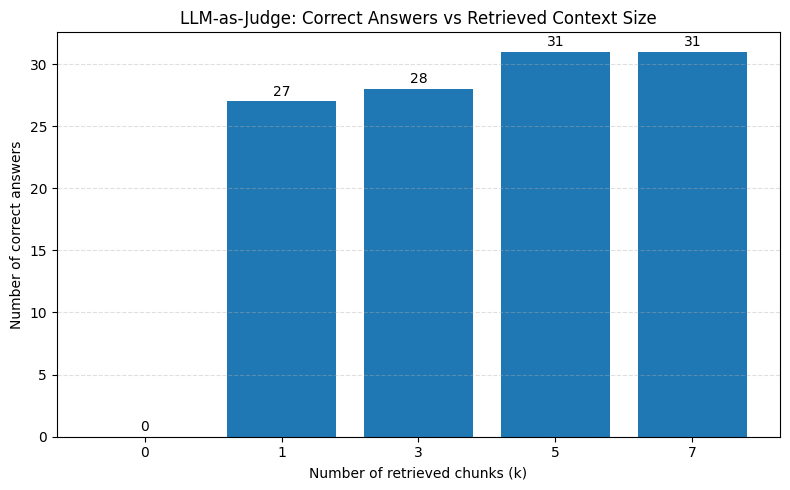

In [19]:
# Bar chart
x = ks
y = [correct_counts[k] for k in ks]

plt.figure(figsize=(8, 5))
bars = plt.bar([str(v) for v in x], y)

plt.xlabel("Number of retrieved chunks (k)")
plt.ylabel("Number of correct answers")
plt.title("LLM-as-Judge: Correct Answers vs Retrieved Context Size")
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add value labels on bars
for b, val in zip(bars, y):
    plt.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.2,
        str(val),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()